#K-Means clustering

When to Use K-Means

     When clusters are spherical
     Data is numeric
     Large datasets
     You know (or can estimate) K

When Not to Use

     Clusters with different shapes (K-means prefers circular blobs)
     Data with many outliers
     When K is unknown (then you must find it first)

## K Means

In [ ]:

import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.cluster import KMeans
from sklearn.metrics import confusion_matrix, accuracy_score

In [ ]:
df = pd.read_csv('/content/data.csv')
X = df[['x', 'y']].values


X.shape

(336, 2)

In [ ]:
plt.figure(figsize=(7,6))
plt.scatter(X[:,0], X[:,1], s=40, alpha=0.8)
plt.title("Original data (x vs y)")
plt.xlabel("x")
plt.ylabel("y")
plt.show()

In [ ]:
inertias = []    #Sum of Squared Distances (SSD) of points to their nearest centroid
K_range = range(1,8)
for k in K_range:
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    kmeans.fit(X)
    inertias.append(kmeans.inertia_)


inertias

Why do we calculate inertia for multiple K values?

    To create the Elbow Plot, used for selecting optimal K.

    Inertia decreases when K increases (clusters get smaller).

    But after a point, the improvement becomes small → “Elbow point”

    This elbow gives the best K.

In [ ]:


plt.figure(figsize=(7,4))
plt.plot(K_range, inertias, '-o')
plt.xticks(K_range)
plt.xlabel("K")
plt.ylabel("Inertia ")
plt.title("Elbow method ")
plt.show()

In [ ]:
no_of_cluster=3
kmeans = KMeans(no_of_cluster, random_state=42, n_init=50)
labels = kmeans.fit_predict(X)
centroids = kmeans.cluster_centers_

df['cluster'] = labels




In [ ]:
plt.figure(figsize=(7,6))
palette = sns.color_palette('tab10', k)
for i in range(no_of_cluster):
    pts = X[labels==i]
    plt.scatter(pts[:,0], pts[:,1], s=40, alpha=0.7, label=f'clusters {i}')

plt.scatter(centroids[:,0], centroids[:,1], marker='X', s=200, c='k', label='Centroids')
plt.legend()
plt.title(f'K-Means clusters (K=3)')
plt.xlabel('x')
plt.ylabel('y')
plt.show()

## DBSCAN

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import make_blobs
from sklearn.cluster import DBSCAN
from sklearn.preprocessing import StandardScaler

In [ ]:
X,_ = make_blobs()
X

array([[ -8.96705099,  11.07686824],
       [  8.98150789,  -2.8322349 ],
       [ -4.97300249, -11.16256196],
       [  7.97009775,  -1.21631756],
       [  6.51067368,  -3.29584902],
       [ -5.77923671, -10.30443322],
       [ -9.5941007 ,   9.47087785],
       [  7.39603765,  -2.90973535],
       [  8.20254537,  -3.04875819],
       [ -9.54775514,   9.57171268],
       [  7.05379484,  -1.42788624],
       [  8.78881168,  -4.63196351],
       [ -9.68654187,   7.98641605],
       [ -7.69027634,   8.00557688],
       [ -7.32887525,   9.57702231],
       [ -2.53159392,  -9.21889859],
       [  8.5440166 ,  -2.87688182],
       [ -9.70384719,  10.77054081],
       [ -5.35344089,  -9.06973609],
       [ -8.38584335,   9.45072568],
       [  6.13944218,  -3.4467027 ],
       [ -4.76429398, -10.51820509],
       [ -8.58846336,  10.78798865],
       [  6.7621384 ,  -3.01488394],
       [  7.89131313,  -3.61499598],
       [  7.96194571,  -2.00108399],
       [  7.47243269,  -2.82591576],
 

In [ ]:
X = StandardScaler().fit_transform(X)


In [ ]:
db = DBSCAN(eps=0.7, min_samples=5, metric='euclidean')
clusters = db.fit_predict(X)

In [ ]:
unique_clusters = clusters


print(unique_clusters)

[0 1 2 1 1 2 0 1 1 0 1 1 0 0 0 2 1 0 2 0 1 2 0 1 1 1 1 2 1 1 2 0 0 2 0 2 0
 1 2 2 0 2 0 2 2 2 1 1 2 0 0 2 1 0 2 0 2 1 0 2 2 1 0 2 0 2 0 0 1 0 2 1 2 0
 2 1 1 0 2 1 0 0 1 2 0 2 1 2 0 0 2 0 1 2 0 1 1 2 1 1]


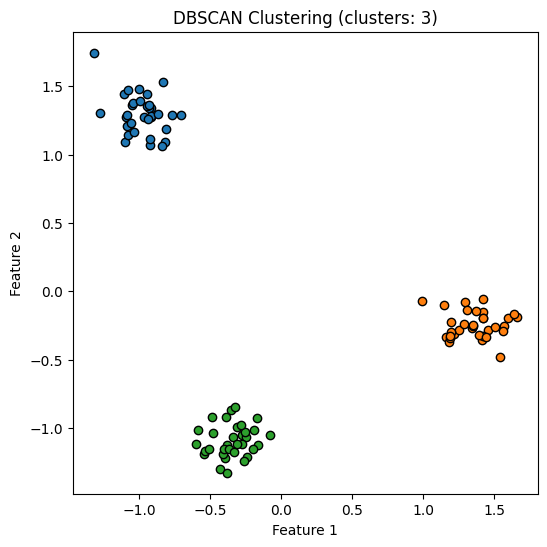

In [ ]:
import seaborn as sns
plt.figure(figsize=(6, 6))
colors = sns.color_palette('tab10')
for k, col in zip(unique_clusters, colors):
    if k == -1:

        col = 'k'
    class_member_mask = (clusters == k)
    xy = X[class_member_mask]
    plt.plot(xy[:, 0], xy[:, 1], 'o', markerfacecolor=col,markeredgecolor='k', markersize=6)

plt.title(f"DBSCAN Clustering (clusters: {len(unique_clusters) - (1 if -1 in clusters else 0)})")
plt.xlabel("Feature 1")
plt.ylabel("Feature 2")
plt.show()
